# 03 — Model Evaluation

Starts from a **fresh kernel**: it only reloads artifacts persisted by
`02_model_training.ipynb` (`.pkl` models, CSV, JSON) — no dependency on any
variable still in memory from 02.

All scoring/health/business logic comes from `src/evaluation.py`, the same
module 02's Optuna objective uses — so there is no way for the two notebooks
to silently disagree on what "healthy" or "significant" means.

Beyond the original evaluation (SHAP, quality checks, health scoring,
business impact, dashboard), this version adds four things a purely
happy-path evaluation misses:
1. **Slice analysis** — error broken down by RUL range, not just a global RMSE.
2. **Robustness testing** — performance under simulated sensor dropout/noise.
3. **Statistical significance** — a bootstrap confidence interval on the
   improvement over baseline, not just two point estimates.
4. **MLflow artifact logging** — evaluation figures/tables attached to the
   exact training run that produced the model, so a reviewer can see them
   without re-running anything.

In [1]:
import sys
import os
import json
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath('../src'))
from evaluation import (
    nasa_score, compute_health_score, get_maintenance_action,
    compute_sliced_metrics, inject_sensor_dropout, inject_gaussian_noise,
    evaluate_under_perturbation, bootstrap_metric_ci,
    check_out_of_distribution, get_shap_explainer, compute_shap_values,
)

plt.style.use('ggplot')
sns.set_palette("viridis")

with open('../configs/config.yaml') as f:
    config = yaml.safe_load(f)

final_model = joblib.load(f"../{config['models']['final_model_path']}")
model_safety = joblib.load(f"../{config['models']['safety_model_path']}")

df_results = pd.read_csv('../data/processed/model_results_final.csv')
X_test_features = pd.read_csv('../data/processed/test_features_engineered.csv')

with open('../data/processed/baseline_metrics.json') as f:
    baseline_metrics = json.load(f)
with open('../data/processed/feature_reference_ranges.json') as f:
    reference_ranges = json.load(f)
with open('../data/processed/run_info.json') as f:
    run_info = json.load(f)

# Resume the exact MLflow run that trained the champion model, so everything
# logged from here on (figures, tables, evaluation metrics) is attached to
# that model version instead of living in a disconnected "evaluation" run.
mlflow.set_tracking_uri(f"sqlite:///{os.path.abspath(os.path.join('..', config['mlflow']['tracking_db']))}")
mlflow.start_run(run_id=run_info['champion_run_id'])

print("--- EVALUATION ENGINE READY ---")
print(f"Unique Engines Analyzed : {df_results['unit'].nunique()}")
print(f"Total Data Points       : {len(df_results)}")
print(f"Resumed MLflow run      : {run_info['champion_run_id']}")

/home/pc/AI/projects/predictive_maintenance/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- EVALUATION ENGINE READY ---
Unique Engines Analyzed : 20
Total Data Points       : 4070
Resumed MLflow run      : 75567b180d9b4b599dcd9d1b06ee443a


## Model Interpretability (SHAP Analysis)

--- GENERATING GLOBAL FEATURE IMPORTANCE ---


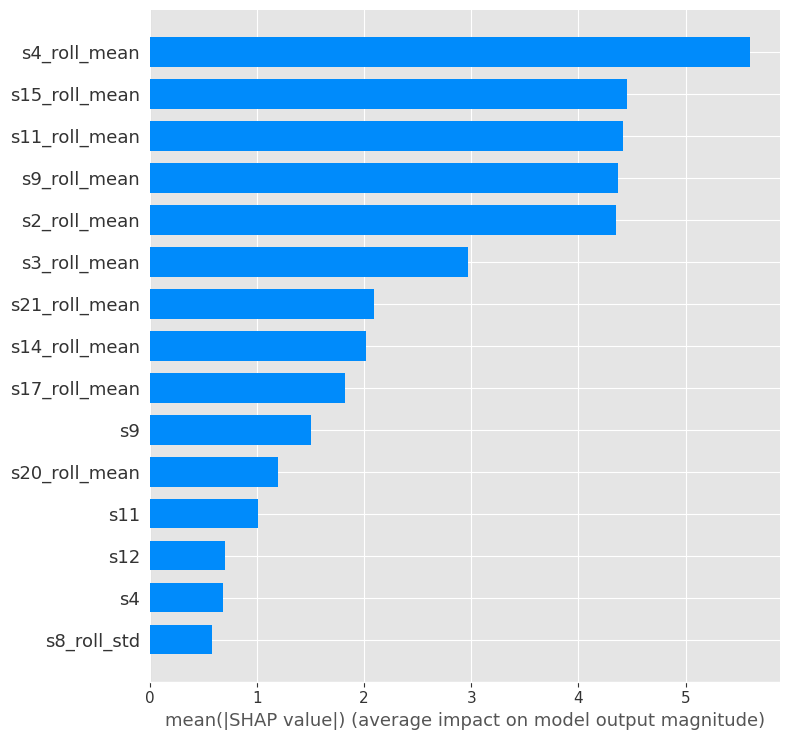

--- GENERATING FEATURE IMPACT DISTRIBUTION ---


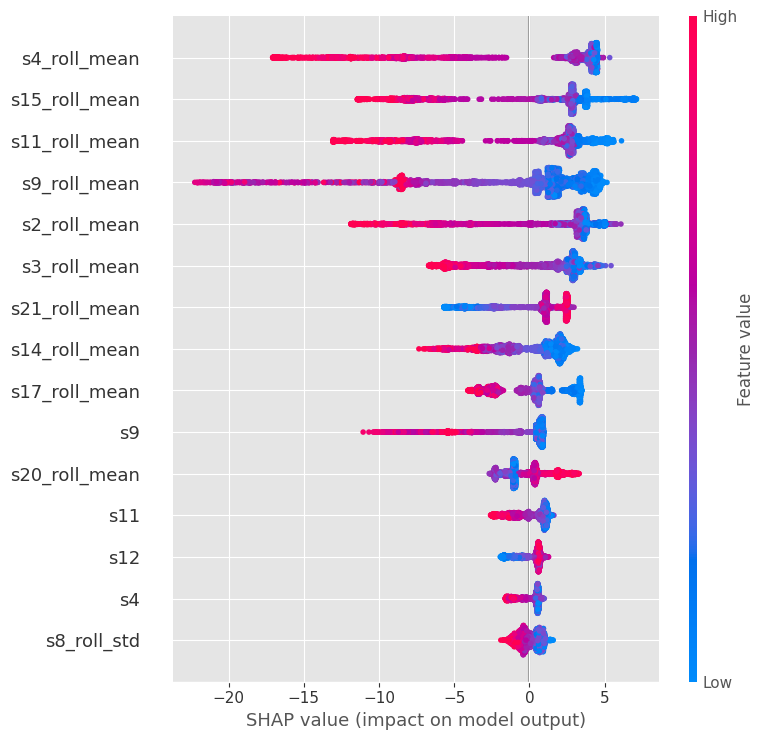

--- TOP 3 MAINTENANCE DRIVERS ---
          feature  importance
36   s4_roll_mean    5.600627
58  s15_roll_mean    4.449634
50  s11_roll_mean    4.414105


In [2]:
shap_features = X_test_features.drop(columns=['unit', 'cycle'], errors='ignore')

explainer = get_shap_explainer(final_model)
shap_values = compute_shap_values(explainer, shap_features)

print("--- GENERATING GLOBAL FEATURE IMPORTANCE ---")
shap.summary_plot(shap_values, shap_features, plot_type="bar", max_display=15, show=False)
fig_shap_bar = plt.gcf()
mlflow.log_figure(fig_shap_bar, "evaluation/shap_feature_importance.png")
plt.show()

print("--- GENERATING FEATURE IMPACT DISTRIBUTION ---")
shap.summary_plot(shap_values, shap_features, max_display=15, show=False)
fig_shap_dist = plt.gcf()
mlflow.log_figure(fig_shap_dist, "evaluation/shap_impact_distribution.png")
plt.show()

vals = np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(shap_features.columns, vals)), columns=['feature', 'importance'])
feature_importance.sort_values(by='importance', ascending=False, inplace=True)

print("--- TOP 3 MAINTENANCE DRIVERS ---")
print(feature_importance.head(3))

## Batch Prediction Quality Check

In [3]:
negative_count = (df_results['predicted_RUL'] < 0).sum()
extreme_outliers = (df_results['predicted_RUL'] > 150).sum()

mean_actual = df_results['RUL'].mean()
mean_predicted = df_results['predicted_RUL'].mean()
bias_check = abs(mean_actual - mean_predicted)

print("--- SYSTEM INTEGRITY REPORT ---")
print(f"Negative Predictions found : {negative_count}")
print(f"Extreme Outliers (>150)    : {extreme_outliers}")
print(f"Mean Actual RUL            : {mean_actual:.2f} cycles")
print(f"Mean Predicted RUL         : {mean_predicted:.2f} cycles")
print(f"System Bias (Difference)   : {bias_check:.2f} cycles")
print("-------------------------------")

if negative_count == 0 and extreme_outliers == 0 and bias_check < 5:
    print("STATUS: SYSTEM IS ROBUST AND READY FOR DEPLOYMENT.")
else:
    print("STATUS: WARNING - Model shows bias or physical inconsistencies.")
    # Applied directly on df_results, so everything downstream (dashboard,
    # export, business impact) uses the corrected version — unlike the
    # original notebook, where this clip was computed once and then discarded.
    df_results['predicted_RUL'] = df_results['predicted_RUL'].clip(0, 150)

mlflow.log_metric("eval_negative_predictions", int(negative_count))
mlflow.log_metric("eval_extreme_outliers", int(extreme_outliers))
mlflow.log_metric("eval_bias_cycles", float(bias_check))

--- SYSTEM INTEGRITY REPORT ---
Negative Predictions found : 0
Extreme Outliers (>150)    : 0
Mean Actual RUL            : 86.30 cycles
Mean Predicted RUL         : 86.12 cycles
System Bias (Difference)   : 0.19 cycles
-------------------------------
STATUS: SYSTEM IS ROBUST AND READY FOR DEPLOYMENT.


## Health Score & Maintenance Actions

--- HEALTH SCORE & MAINTENANCE ACTIONS ---
   unit  cycle  predicted_RUL  safety_RUL  health_score maintenance_action
0     1      1     126.377890  124.623245     99.698596   Normal Operation
1     1      2     118.508130  117.668270     94.134616   Normal Operation
2     1      3     121.844570  121.777450     97.421960   Normal Operation
3     1      4     121.389330  120.865944     96.692755   Normal Operation
4     1      5     122.539444  121.373100     97.098480   Normal Operation
5     1      6     120.895010  119.940530     95.952424   Normal Operation
6     1      7     121.668650  120.735080     96.588064   Normal Operation
7     1      8     121.519040  120.628330     96.502664   Normal Operation
8     1      9     121.683130  120.875020     96.700016   Normal Operation
9     1     10     121.656800  121.425545     97.140436   Normal Operation


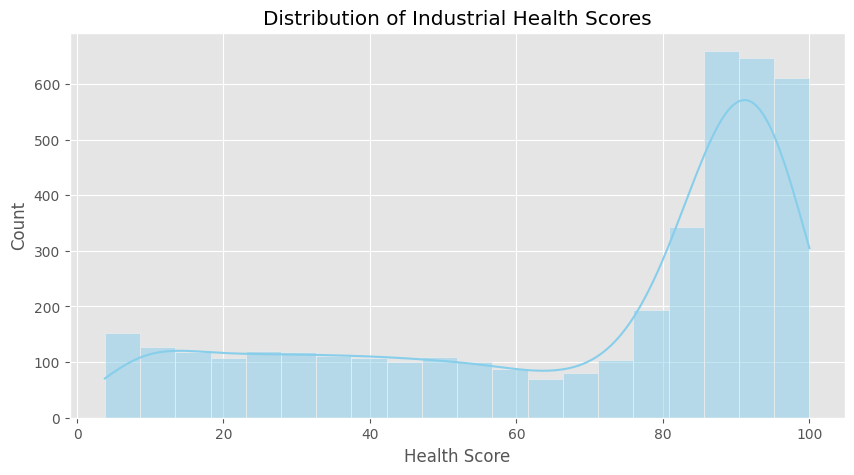


Maintenance Action Counts:
maintenance_action
Normal Operation       2935
Schedule Inspection     701
IMMEDIATE GROUNDING     434
Name: count, dtype: int64


In [4]:
df_results['health_score'] = compute_health_score(df_results['safety_RUL'], max_rul_cap=config['data']['max_rul'])
df_results['maintenance_action'] = df_results['health_score'].apply(
    lambda s: get_maintenance_action(
        s,
        inspect_threshold=config['health_score']['inspect_threshold'],
        ground_threshold=config['health_score']['ground_threshold']
    )
)

print("--- HEALTH SCORE & MAINTENANCE ACTIONS ---")
print(df_results[['unit', 'cycle', 'predicted_RUL', 'safety_RUL', 'health_score', 'maintenance_action']].head(10))

plt.figure(figsize=(10, 5))
sns.histplot(df_results['health_score'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Industrial Health Scores")
plt.xlabel("Health Score")
plt.ylabel("Count")
fig_health_dist = plt.gcf()
mlflow.log_figure(fig_health_dist, "evaluation/health_score_distribution.png")
plt.show()

print("\nMaintenance Action Counts:")
action_counts = df_results['maintenance_action'].value_counts()
print(action_counts)
for action, count in action_counts.items():
    mlflow.log_metric(f"count_{action.lower().replace(' ', '_')}", int(count))

## Slice Analysis

A single global RMSE hides exactly the cases that matter most: being off by
10 cycles when 100 remain is harmless, the same error when 5 remain is
dangerous. Breaking the error down by true-RUL range makes this visible.

--- ERROR BY RUL RANGE ---
 rul_range    n      rmse       mae  mean_bias
   [0, 20)  400  6.528378  5.301454   4.714312
  [20, 50)  600 19.760120 13.083783   9.230074
 [50, 100) 1000 23.149655 19.018683  10.682096
[100, inf) 2070 12.634585 10.139118  -9.113260


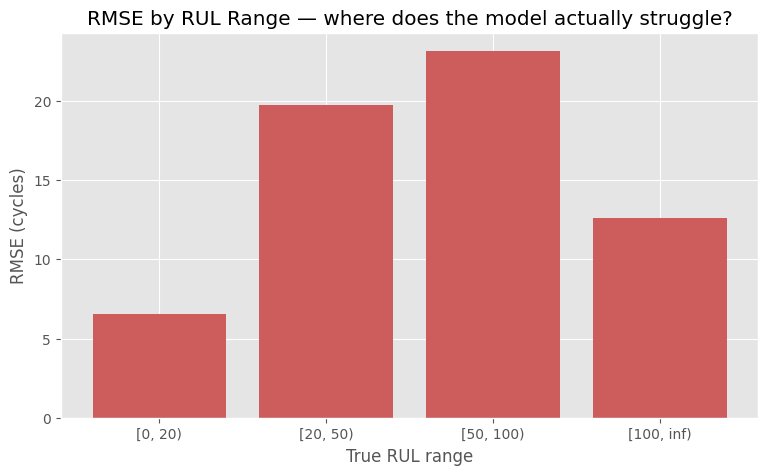


RMSE in the critical zone (RUL < 20): 6.53 cycles


In [5]:
slice_bins = [tuple(b) for b in config['evaluation']['rul_slice_bins']]
sliced = compute_sliced_metrics(df_results['RUL'], df_results['predicted_RUL'], bins=slice_bins)

print("--- ERROR BY RUL RANGE ---")
print(sliced.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(sliced['rul_range'], sliced['rmse'], color='indianred')
ax.set_title('RMSE by RUL Range — where does the model actually struggle?')
ax.set_ylabel('RMSE (cycles)')
ax.set_xlabel('True RUL range')
mlflow.log_figure(fig, "evaluation/slice_analysis_rmse.png")
plt.show()

critical_slice = sliced[sliced['rul_range'].str.startswith('[0,')]
if not critical_slice.empty:
    critical_rmse = critical_slice['rmse'].iloc[0]
    print(f"\nRMSE in the critical zone (RUL < 20): {critical_rmse:.2f} cycles")
    mlflow.log_metric("rmse_critical_zone", float(critical_rmse))

## Robustness Testing (Sensor Dropout & Noise)

Evaluation on clean held-out data says nothing about behavior when a sensor
fails or drifts — which is the normal case in production, not the
exception. This simulates both and reports how much RMSE degrades.

In [6]:
perturbations = {
    "sensor_dropout": inject_sensor_dropout(
        shap_features,
        fraction=config['evaluation']['stress_sensor_dropout_fraction'],
        seed=config['split']['random_state']
    ),
    "gaussian_noise": inject_gaussian_noise(
        shap_features,
        sigma_pct=config['evaluation']['stress_gaussian_noise_sigma_pct'],
        seed=config['split']['random_state']
    ),
}

robustness = evaluate_under_perturbation(final_model, shap_features, df_results['RUL'], perturbations)
print("--- ROBUSTNESS UNDER PERTURBATION ---")
print(robustness.to_string(index=False))

for _, row in robustness.iterrows():
    mlflow.log_metric(f"rmse_stress_{row['scenario']}", float(row['rmse']))

worst_case_degradation = robustness['rmse_degradation_pct'].iloc[1:].max()
if worst_case_degradation > 25:
    print(f"\nWARNING: worst-case degradation is {worst_case_degradation:.1f}% — "
          f"consider input validation or sensor-fault detection before serving.")
else:
    print(f"\nWorst-case degradation: {worst_case_degradation:.1f}% — model degrades gracefully.")

--- ROBUSTNESS UNDER PERTURBATION ---
      scenario      rmse  rmse_degradation_pct
         clean 16.571427              0.000000
sensor_dropout 16.654533              0.501504
gaussian_noise 16.539756             -0.191114

Worst-case degradation: 0.5% — model degrades gracefully.


## Statistical Significance vs Baseline

Two point-estimate RMSE numbers can't say whether the champion model is
*actually* better than the linear baseline, or whether the gap is small
enough to be an artifact of which engines landed in the test split. A paired
bootstrap on the RMSE difference gives a confidence interval instead of a
single number.

In [7]:
rmse_ci = bootstrap_metric_ci(
    df_results['RUL'], df_results['baseline_predicted_RUL'], df_results['predicted_RUL'],
    n_boot=config['evaluation']['bootstrap_n_resamples'],
    ci=config['evaluation']['bootstrap_ci_level'],
    seed=config['split']['random_state']
)

print("--- BOOTSTRAP CI: RMSE(baseline) - RMSE(champion) ---")
print(f"Point estimate : {rmse_ci['point_estimate']:.2f} cycles")
print(f"{int(rmse_ci['ci_level']*100)}% CI       : [{rmse_ci['ci_low']:.2f}, {rmse_ci['ci_high']:.2f}]")
print(f"Significant    : {rmse_ci['significant']} "
      f"({'CI excludes 0 — the improvement is unlikely to be noise' if rmse_ci['significant'] else 'CI includes 0 — improvement is not distinguishable from noise at this sample size'})")

mlflow.log_metric("rmse_improvement_point_estimate", rmse_ci['point_estimate'])
mlflow.log_metric("rmse_improvement_ci_low", rmse_ci['ci_low'])
mlflow.log_metric("rmse_improvement_ci_high", rmse_ci['ci_high'])

--- BOOTSTRAP CI: RMSE(baseline) - RMSE(champion) ---
Point estimate : 3.20 cycles
95% CI       : [2.77, 3.65]
Significant    : True (CI excludes 0 — the improvement is unlikely to be noise)


## Error Diagnostic (Reliability over Lifetime)

Reliability diagnostic plot saved successfully.


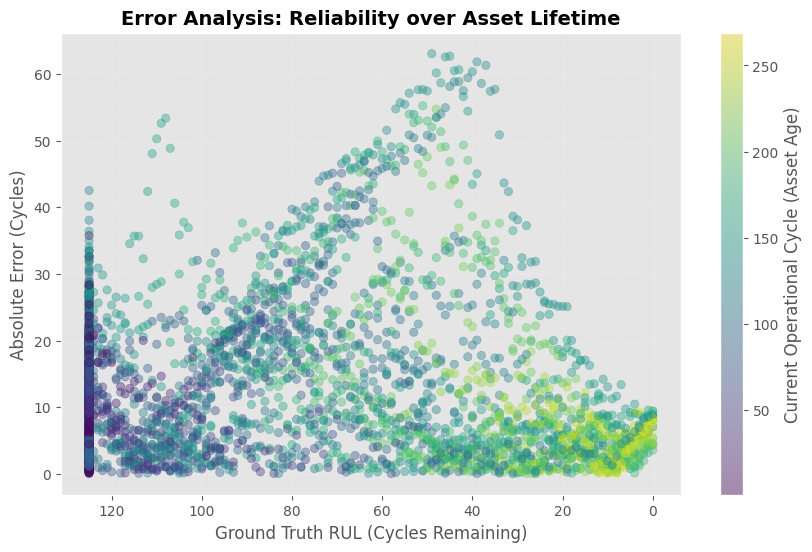

In [8]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    df_results['RUL'], df_results['absolute_error'],
    alpha=0.4, c=df_results['cycle'], cmap='viridis'
)
plt.xlabel('Ground Truth RUL (Cycles Remaining)')
plt.ylabel('Absolute Error (Cycles)')
plt.title('Error Analysis: Reliability over Asset Lifetime', fontsize=14, fontweight='bold')
plt.gca().invert_xaxis()
plt.colorbar(sc, label='Current Operational Cycle (Asset Age)')
plt.grid(True, alpha=0.2, linestyle='--')

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/error_reliability_analysis.png', dpi=300, bbox_inches='tight')
fig_reliability = plt.gcf()
mlflow.log_figure(fig_reliability, "evaluation/error_reliability_analysis.png")
print("Reliability diagnostic plot saved successfully.")
plt.show()

## Business Impact & Cost Savings

In [9]:
cost_unplanned_failure = config['business']['cost_unplanned_failure']
cost_preventive_maint = config['business']['cost_preventive_maintenance']
cost_false_positive = config['business']['cost_false_positive']
CRITICAL_THRESHOLD = config['business']['critical_threshold_cycles']
ALERT_THRESHOLD = config['business']['alert_threshold_cycles']

missed_failures = ((df_results['RUL'] < CRITICAL_THRESHOLD) & (df_results['predicted_RUL'] > ALERT_THRESHOLD)).sum()
prevented_failures = ((df_results['RUL'] < ALERT_THRESHOLD) & (df_results['predicted_RUL'] <= ALERT_THRESHOLD)).sum()
false_positives = ((df_results['RUL'] >= ALERT_THRESHOLD) & (df_results['predicted_RUL'] <= ALERT_THRESHOLD)).sum()

gains = prevented_failures * (cost_unplanned_failure - cost_preventive_maint)
loss_missed_failures = missed_failures * cost_unplanned_failure
loss_false_positives = false_positives * cost_false_positive
net_savings = gains - loss_missed_failures - loss_false_positives

print(f"Critical failures prevented : {prevented_failures}")
print(f"Critical failures missed    : {missed_failures} (cost: ${loss_missed_failures:,})")
print(f"False alarms                : {false_positives} (cost: ${loss_false_positives:,})")
print(f"Estimated NET savings       : ${net_savings:,}")

# Bootstrap CI on the champion's net savings vs. what the baseline would have
# produced under the same cost model — same logic as the RMSE CI above,
# applied to the business metric that actually matters to a stakeholder.
def _net_savings_fn(y_true_arr, y_pred_arr):
    yt, yp = np.asarray(y_true_arr), np.asarray(y_pred_arr)
    missed = ((yt < CRITICAL_THRESHOLD) & (yp > ALERT_THRESHOLD)).sum()
    prevented = ((yt < ALERT_THRESHOLD) & (yp <= ALERT_THRESHOLD)).sum()
    false_pos = ((yt >= ALERT_THRESHOLD) & (yp <= ALERT_THRESHOLD)).sum()
    return float(prevented * (cost_unplanned_failure - cost_preventive_maint)
                 - missed * cost_unplanned_failure - false_pos * cost_false_positive)

savings_ci = bootstrap_metric_ci(
    df_results['RUL'], df_results['predicted_RUL'], df_results['baseline_predicted_RUL'],
    metric_fn=_net_savings_fn,
    n_boot=config['evaluation']['bootstrap_n_resamples'],
    ci=config['evaluation']['bootstrap_ci_level'],
    seed=config['split']['random_state']
)
print(f"\nNet savings advantage over baseline, {int(savings_ci['ci_level']*100)}% CI : "
      f"[${savings_ci['ci_low']:,.0f}, ${savings_ci['ci_high']:,.0f}]")

mlflow.log_metric("net_savings_usd", net_savings)
mlflow.log_metric("net_savings_advantage_ci_low", savings_ci['ci_low'])
mlflow.log_metric("net_savings_advantage_ci_high", savings_ci['ci_high'])

Critical failures prevented : 136
Critical failures missed    : 12 (cost: $600,000)
False alarms                : 12 (cost: $24,000)
Estimated NET savings       : $4,816,000

Net savings advantage over baseline, 95% CI : [$231,900, $2,132,200]


## Operational Decision Dashboard

Dashboard saved at: ../reports/figures/engine_1_operational_report.png


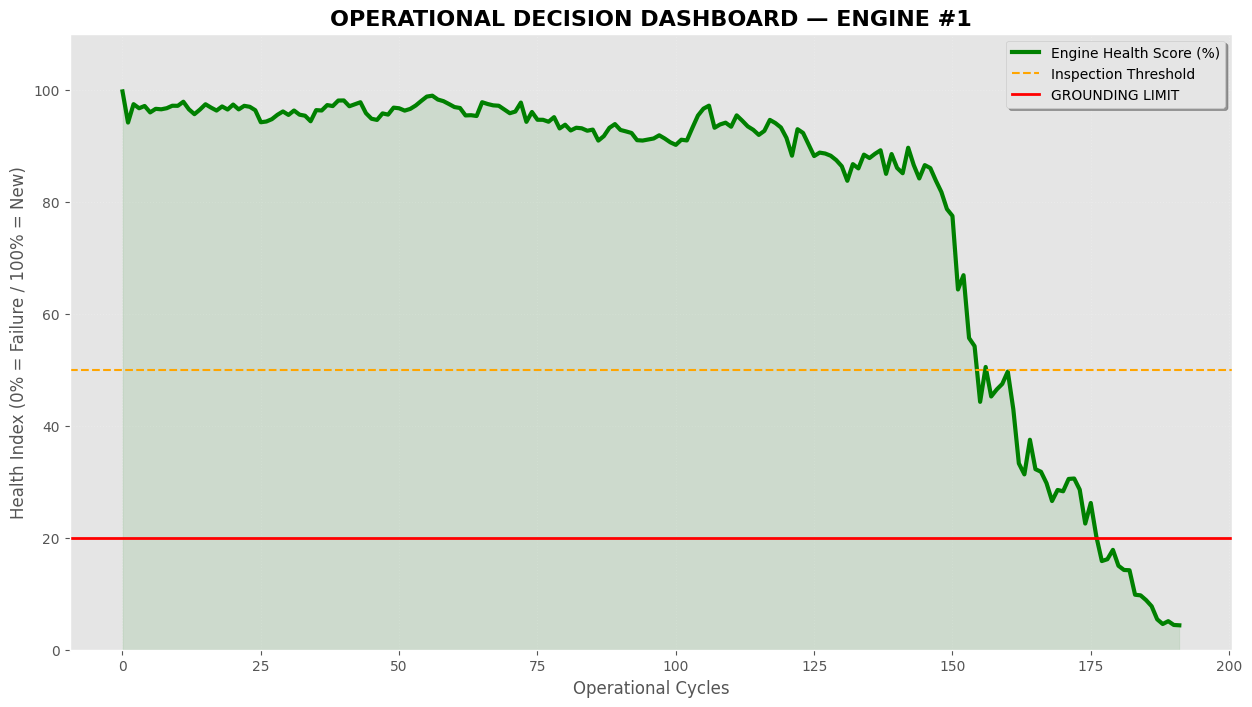


--- TOP 15 CRITICAL ENGINES (fleet-wide, most recent known cycle per engine) ---
      unit  cycle  health_score   maintenance_action
1997    40    188      3.805830  IMMEDIATE GROUNDING
3196    77    154      4.357654  IMMEDIATE GROUNDING
191      1    192      4.361964  IMMEDIATE GROUNDING
700     11    240      4.405164  IMMEDIATE GROUNDING
2668    54    257      4.463344  IMMEDIATE GROUNDING
460      5    269      4.642863  IMMEDIATE GROUNDING
863     13    163      4.697557  IMMEDIATE GROUNDING
2876    71    208      4.741596  IMMEDIATE GROUNDING
1423    31    234      4.811017  IMMEDIATE GROUNDING
2411    46    256      4.832751  IMMEDIATE GROUNDING
3667    81    240      4.906766  IMMEDIATE GROUNDING
3042    74    166      5.208400  IMMEDIATE GROUNDING
1189    23    168      5.313012  IMMEDIATE GROUNDING
3934    84    267      5.575547  IMMEDIATE GROUNDING
1809    34    195      5.621970  IMMEDIATE GROUNDING


In [10]:
unit_id = df_results['unit'].unique()[0]
engine_results = df_results[df_results['unit'] == unit_id].sort_values('cycle')

fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.plot(engine_results['health_score'].values, color='green', linewidth=3, label='Engine Health Score (%)')
ax1.fill_between(range(len(engine_results)), 0, engine_results['health_score'].values, color='green', alpha=0.1)

ax1.axhline(y=config['health_score']['inspect_threshold'], color='orange', linestyle='--', label='Inspection Threshold')
ax1.axhline(y=config['health_score']['ground_threshold'], color='red', linestyle='-', linewidth=2, label='GROUNDING LIMIT')

ax1.set_title(f'OPERATIONAL DECISION DASHBOARD — ENGINE #{unit_id}', fontsize=16, fontweight='bold')
ax1.set_ylabel('Health Index (0% = Failure / 100% = New)', fontsize=12)
ax1.set_xlabel('Operational Cycles', fontsize=12)
ax1.set_ylim(0, 110)
ax1.legend(loc='upper right', frameon=True, shadow=True)
ax1.grid(True, alpha=0.2, linestyle=':')

file_name = f'../reports/figures/engine_{unit_id}_operational_report.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')
mlflow.log_figure(fig, "evaluation/operational_dashboard.png")
print(f"Dashboard saved at: {file_name}")
plt.show()

print("\n--- TOP 15 CRITICAL ENGINES (fleet-wide, most recent known cycle per engine) ---")
latest_per_unit = df_results.sort_values('cycle').groupby('unit').tail(1)
critical_table = (latest_per_unit[['unit', 'cycle', 'health_score', 'maintenance_action']]
                   .sort_values('health_score').head(15))
print(critical_table)
mlflow.log_table(critical_table, "evaluation/top_critical_engines.json")

## Global Performance Summary

In [11]:
rmse_final = np.sqrt(mean_squared_error(df_results['RUL'], df_results['predicted_RUL']))
r2_final = r2_score(df_results['RUL'], df_results['predicted_RUL'])
nasa_final = nasa_score(df_results['RUL'], df_results['predicted_RUL'])

summary_df = pd.DataFrame({
    "Metric": ["RMSE", "R2 Score", "NASA Score", "Average Predicted RUL"],
    "Baseline (Linear)": [f"{baseline_metrics['rmse_baseline']:.2f}", "-", f"{baseline_metrics['nasa_baseline']:.0f}", "-"],
    "Champion (XGBoost)": [f"{rmse_final:.2f}", f"{r2_final:.4f}", f"{nasa_final:.0f}", f"{df_results['predicted_RUL'].mean():.1f} cycles"],
    "Safety Bound (Quantile)": ["-", "-", "-", f"{df_results['safety_RUL'].mean():.1f} cycles"]
})

print("--- FINAL PROJECT PERFORMANCE SUMMARY ---")
print(summary_df.to_string(index=False))
mlflow.log_table(summary_df, "evaluation/performance_summary.json")

nasa_improvement = (baseline_metrics['nasa_baseline'] - nasa_final) / baseline_metrics['nasa_baseline'] * 100
print(f"\nNASA Score improvement vs baseline : {nasa_improvement:.1f}%")
print(f"Statistically significant (bootstrap {int(rmse_ci['ci_level']*100)}% CI) : {rmse_ci['significant']}")

--- FINAL PROJECT PERFORMANCE SUMMARY ---
               Metric Baseline (Linear) Champion (XGBoost) Safety Bound (Quantile)
                 RMSE             19.78              16.57                       -
             R2 Score                 -             0.8422                       -
           NASA Score             26644              34115                       -
Average Predicted RUL                 -        86.1 cycles             86.3 cycles

NASA Score improvement vs baseline : -28.0%
Statistically significant (bootstrap 95% CI) : True


## Out-of-Distribution Guard — Validation

Sanity-checks the OOD guard itself: on genuinely held-out, legitimately clean
test data, it should rarely fire. If it flags a large share of normal rows,
the thresholds are too tight and would create alert fatigue in production.

In [12]:
ood_flags = shap_features.apply(
    lambda row: check_out_of_distribution(
        row, reference_ranges, max_violation_ratio=config['evaluation']['ood_max_violation_ratio']
    )['is_ood'],
    axis=1
)

ood_rate = ood_flags.mean()
print(f"--- OOD GUARD VALIDATION (on clean held-out test data) ---")
print(f"Flagged as out-of-distribution: {ood_flags.sum()} / {len(ood_flags)} ({ood_rate:.1%})")

if ood_rate > 0.05:
    print("WARNING: guard fires on more than 5% of clean data — thresholds may be too tight.")
else:
    print("OK: guard stays quiet on clean data, as expected.")

mlflow.log_metric("ood_false_positive_rate_on_clean_test", float(ood_rate))

--- OOD GUARD VALIDATION (on clean held-out test data) ---
Flagged as out-of-distribution: 89 / 4070 (2.2%)
OK: guard stays quiet on clean data, as expected.


## Limitations & Assumptions

- The model may underperform on engine types or operating conditions never
  seen in training (this project trains on FD001 only — a single operating
  condition, a single fault mode).
- Predictions assume clean, continuously available sensor data; the
  robustness section above quantifies — rather than assumes — how much
  performance degrades when that assumption breaks.
- Health score thresholds (`inspect_threshold`, `ground_threshold` in
  `config.yaml`) are heuristic and should be recalibrated against a real fleet.
- The out-of-distribution guard is a percentile-range heuristic, not a
  calibrated statistical test — it flags obviously unusual input, it does not
  bound false-negative risk.
- This evaluation assumes an identical feature pipeline between training and
  inference — see `src/inference.py`, which recomputes features explicitly to
  guarantee that.

## Deployment Strategy

- Serve the model through the FastAPI layer (`api/main.py`) for real-time RUL
  predictions, calling `src/inference.py` (`predict_with_explanation` for
  operator-facing output) — no logic duplicated between notebook and API.
- Monitor sensor data drift in production (Evidently — planned next phase).
- Validate incoming sensor readings (missing/aberrant values, and the
  out-of-distribution guard above) before inference.
- Retrain periodically (`dvc repro`) as new operational data arrives.
- These notes also live in `docs/deployment.md` — keep them in sync, or
  generate this page automatically once MkDocs is wired up (next phase).

In [13]:
mlflow.end_run()
print("Evaluation artifacts logged to MLflow run:", run_info['champion_run_id'])

Evaluation artifacts logged to MLflow run: 75567b180d9b4b599dcd9d1b06ee443a
